# **Modelo Original PWVM - Probabilistic Weight Voting Model**

Se implementó el **Probabilistic Weighted Voting Model (PWVM)**, un esquema de ensemble avanzado propuesto originalmente por Ülker y Küçüker (2022) para detección y clasificación de fallas en microgrids, el cual adaptamos al dominio de predicción de diabetes. Este modelo fue planteado inicialmente para resolver problemas de clasificación complejos en sistemas de potencia, donde se requería alta precisión en la identificación de múltiples tipos de fallas eléctricas bajo condiciones ruidosas y distribuciones desbalanceadas.

El **PWVM** representa una evolución significativa respecto a los ensembles convencionales al incorporar un esquema matricial de ponderación que considera no solo la precisión global de cada clasificador, sino su desempeño específico por categoría. Este enfoque de ensemble avanzado supera las limitaciones de los métodos de votación tradicionales mediante:

* **Combinación probabilística ponderada:** En lugar de votación por mayoría simple, se utiliza un esquema matricial de pesos que considera el rendimiento individual de cada clasificador por clase

* **Métricas de validación robustas:** Implementación de F-score por clase individual y MAE ajustado (MAE* = 1 - MAE) para calcular pesos óptimos

* **Normalización de contribuciones:** Los pesos se normalizan por clase asegurando suma unitaria, garantizando balance en el ensemble

* **Arquitectura de ensemble diversificada:** Combinación estratégica de 5 algoritmos complementarios (SVM, CatBoost, LightGBM, Regresión Logística, XGBoost) 

**Referencia:** Ülker, F., & Küçüker, A. (2022). Probabilistic weighted voting model using multiple machine learning methods for fault detection and classification. COMPEL - The International Journal for Computation and Mathematics in Electrical and Electronic Engineering, 41(5), 1542-1565. https://www-webofscience-com.ezproxy.uninorte.edu.co/wos/woscc/full-record/WOS:000758936500001

## **Librerías**

Se importan las librerías esenciales para facilitar el análisis, que abarca la carga de datos, la visualización, la transformación, la fusión y la unión. Además, se configura el entorno para suprimir las advertencias (`warnings`) y asegurar que la salida del código sea más limpia y enfocada en los resultados.

In [190]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scipy
from sklearn.metrics import mean_absolute_error, f1_score
import os
import joblib
from scipy.stats.mstats import winsorize
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, KBinsDiscretizer, MinMaxScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer
from catboost import CatBoostClassifier
from ucimlrepo import fetch_ucirepo 
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

## **Carga de datos**

Se Importa la función `fetch_ucirepo` del paquete `ucimlrepo`.

`fetch_ucirepo` es la función clave para descargar datasets usando su ID único.

In [191]:
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 
  
X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets 

df = pd.concat([X, y], axis=1) 

## **Estrategia de Preprocesamiento Diferenciado por Tipo de Variable**

Para facilitar el preprocesamiento diferenciado según el tipo de variable, categorizamos las features en tres grupos estratégicos: `binarias`, `categóricas` y `numéricas`. Esta división metodológica nos permitirá aplicar transformaciones específicas y apropiadas a cada tipo de variable durante la construcción del pipeline de machine learning, optimizando así el rendimiento de los modelos.

In [192]:
binarias = [col for col in df.columns if df[col].nunique() == 2]
categoricas = ['GenHlth', 'Age', 'Education', 'Income']
numericas = ['MentHlth', 'PhysHlth', 'BMI']

### **Tratamiento Valores atípicos**

Para el tratamiento de valores atípicos en la variable `BMI`, se aplicó la técnica de winsorización al 1% exclusivamente en el extremo superior de la distribución. Esta decisión se fundamentó en los hallazgos del análisis exploratorio de datos (EDA), donde se identificó la presencia de valores extremos significativos que podían distorsionar los modelos predictivos. Las razones específicas que justifican este enfoque son:

* **Preservar la integridad de la muestra** manteniendo todos los registros.

* **Minimizar la influencia de valores extremos** en el rango de obesidad severa.

* **Conservar los valores de bajo peso** según tablas médicas establecidas, ya que la winsorización en el límite inferior habría eliminado casos válidos de delgadez severa que son clínicamente relevantes.

In [193]:
df['BMI'] = winsorize(df['BMI'], limits=[0, 0.01])

### **Tratamiento Multicolinealidad**

A continuación hallamos el VIF el cual determina la fuerza de la correlación entre las variables independientes. Se pronostica tomando una variable y comparándola con todas las demás. La puntuación VIF de una variable independiente representa hasta qué punto la variable se explica por otras variables independientes.

* Un valor `VIF de 1`: Sin multicolinealidad (variable perfectamente independiente).

* Un valor `VIF entre 1 y 5`: Multicolinealidad baja a moderada (no se considera problemática).

* Un valor `VIF entre 5 y 10`: Multicolinealidad moderada a alta (considerada problemática).

* Un valor `VIF superior a 10`: Multicolinealidad alta (preocupación grave, requiere medidas).

In [194]:
df_vif = df[numericas+binarias]

def VIF_calculation(X):
    VIF = pd.DataFrame()
    VIF["variable"] = X.columns
    VIF["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    VIF = VIF.sort_values('VIF', ascending=False).reset_index(drop = True)
    return(VIF)

VIF_mat = VIF_calculation(df_vif)
display(VIF_mat)

,variable,VIF
0,CholCheck,20.479390
1,BMI,17.902974
2,AnyHealthcare,17.282353
3,Veggies,5.587005
4,PhysActivity,4.446659
5,Fruits,2.974917
6,HighBP,2.166592
7,HighChol,1.985175
8,Smoker,1.883938
9,Sex,1.858116


Procedemos a tratar la multicolinealidad mediante la identifición iterativa de variables con Factor de Inflación de la Varianza (VIF) superior a 10. Este enfoque sistemático nos permite remover las variables que presentan alta correlación con otras variables predictoras.

In [195]:
removed_features = []
threshold = 10

print("Proceso iterativo de eliminación por VIF:")
print("-----------------------------------------")

for i in range(df_vif.shape[1]): 
    vif_df = VIF_calculation(df_vif)
    max_vif = vif_df['VIF'].iloc[0]
    max_feature = vif_df['variable'].iloc[0]
    
    if max_vif > threshold:
        print(f"Round {i+1}: Eliminando '{max_feature}' con VIF = {max_vif:.2f}")
        df_vif.drop(columns=[max_feature], inplace=True)
        removed_features.append(max_feature)
    else:
        print(f"\n¡Proceso completado! Todas las variables tienen VIF < {threshold}.")
        break

Proceso iterativo de eliminación por VIF:
-----------------------------------------
Round 1: Eliminando 'CholCheck' con VIF = 20.48
Round 2: Eliminando 'BMI' con VIF = 14.76

¡Proceso completado! Todas las variables tienen VIF < 10.


### **Remoción de variables con alta multicolinealidad**

Como parte del preprocesamiento de datos, se eliminan variables con alta multicolinealidad identificadas mediante análisis de Factor de Inflación de la Variancia (VIF). Esta decisión se aplicó específicamente al conjunto de variables inicial que incluía:

* `binarias`
* `numericas`
* `categoricas`

In [196]:
binarias = [col for col in binarias if col not in removed_features and col != "Diabetes_binary"]
binarias

['HighBP',
 'HighChol',
 'Smoker',
 'Stroke',
 'HeartDiseaseorAttack',
 'PhysActivity',
 'Fruits',
 'Veggies',
 'HvyAlcoholConsump',
 'AnyHealthcare',
 'NoDocbcCost',
 'DiffWalk',
 'Sex']

In [197]:
categoricas = [col for col in categoricas if col not in removed_features]
categoricas

['GenHlth', 'Age', 'Education', 'Income']

In [198]:
numericas = [col for col in numericas if col not in removed_features]
numericas

['MentHlth', 'PhysHlth']

Esta depuración resulta particularmente beneficiosa para modelos como la Regresión Logística y SVM que son sensibles a la multicolinealidad, mientras que los métodos basados en árboles como XGBoost y LightGBM se ven menos afectados pero igualmente se benefician de un espacio de features más eficiente y representativo.

## **Creación del Conjunto de Entrenamiento y Prueba para Modelado Optimizado**

Para evaluar de manera rigurosa y justa el desempeño de los modelos optimizados, es esencial probarlos en datos que no hayan sido utilizados durante el proceso de balanceo de clases ni de ajuste de hiperparámetros. Por esta razón, se divide el dataset en subconjuntos de entrenamiento y prueba antes de aplicar cualquier técnica de optimización.

In [199]:
X = df[numericas+binarias+categoricas]
y = df['Diabetes_binary']

In [200]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Un 20% de los datos se asigna para prueba, utilizando una semilla (`random_state=42`) para asegurar la reproducibilidad de la partición.

## **Implementación Modelo original - PWVM** 

### **PWVM - Train**

La función `pwvm_train` es el componente de entrenamiento del ensemble PWVM, responsable de calcular los pesos óptimos para cada combinación modelo-clase. Su objetivo principal es determinar cuánto debe contribuir cada clasificador a la decisión final según su rendimiento específico.

In [201]:
def pwvm_train(models, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    #Estructura para la matriz de pesos (ecuación 17 del paper)
    fscore_class0_per_fold = {name: [] for name in models}
    fscore_class1_per_fold = {name: [] for name in models}
    mae_per_fold = {name: [] for name in models}

    for train_idx, val_idx in skf.split(X, y):
        X_tr = X.iloc[train_idx].reset_index(drop=True)
        X_val = X.iloc[val_idx].reset_index(drop=True)
        y_tr = y.iloc[train_idx].reset_index(drop=True)
        y_val = y.iloc[val_idx].reset_index(drop=True)

        for name, model in models.items():
            try:
                #probabilidades
                if hasattr(model, "predict_proba"):
                    proba = model.predict_proba(X_val)
                    proba_class1 = proba[:, 1]
                elif hasattr(model, "decision_function"):
                    raw = model.decision_function(X_val)
                    proba_class1 = 1 / (1 + np.exp(-raw))
                else:
                    preds = model.predict(X_val)
                    proba_class1 = preds.astype(float)

                #F-SCORE POR CLASE (ecuación 14)
                #Clase 0
                y_true_class0 = (y_val == 0).astype(int)
                y_pred_class0 = (proba_class1 < 0.5).astype(int)
                f1_class0 = f1_score(y_true_class0, y_pred_class0, zero_division=0)
                fscore_class0_per_fold[name].append(f1_class0)
                
                #Clase 1  
                y_true_class1 = (y_val == 1).astype(int)
                y_pred_class1 = (proba_class1 >= 0.5).astype(int)
                f1_class1 = f1_score(y_true_class1, y_pred_class1, zero_division=0)
                fscore_class1_per_fold[name].append(f1_class1)

                #CALCULAR MAE (ecuación 15)
                true_probs = np.where(y_val == 1, 1.0, 0.0)
                mae = mean_absolute_error(true_probs, proba_class1)
                mae_per_fold[name].append(mae)
                
            except ValueError as e:
                if "feature" in str(e).lower() and "expected" in str(e).lower():
                    print(f"Saltando modelo {name} en fold por error de dimensiones")
                    fscore_class0_per_fold[name].append(0.001)
                    fscore_class1_per_fold[name].append(0.001)
                    mae_per_fold[name].append(0.9)  
                else:
                    raise e

    #MATRIZ DE PESOS (ecuación 17)
    pesos_por_clase = {}
    
    for name in models:
        #Promedio de métricas por fold
        fscore_class0 = np.mean(fscore_class0_per_fold[name])
        fscore_class1 = np.mean(fscore_class1_per_fold[name])
        mae = np.mean(mae_per_fold[name])
        
        # MAE* = 1 - MAE (ecuación 16)
        mae_adj = 1 - mae
        
        #w_m = [F-score] · [MAE*] (ecuación 17)
        peso_clase0 = fscore_class0 * mae_adj
        peso_clase1 = fscore_class1 * mae_adj
        
        pesos_por_clase[name] = {
            'clase0': peso_clase0,
            'clase1': peso_clase1
        }

    #NORMALIZAR PESOS POR CLASE (ecuación 13)
    suma_pesos_clase0 = sum(pesos_por_clase[name]['clase0'] for name in models)
    suma_pesos_clase1 = sum(pesos_por_clase[name]['clase1'] for name in models)
    
    pesos_normalizados = {}
    for name in models:
        if suma_pesos_clase0 > 0:
            peso_norm_0 = pesos_por_clase[name]['clase0'] / suma_pesos_clase0
        else:
            peso_norm_0 = 1.0 / len(models)
            
        if suma_pesos_clase1 > 0:
            peso_norm_1 = pesos_por_clase[name]['clase1'] / suma_pesos_clase1
        else:
            peso_norm_1 = 1.0 / len(models)
        
        pesos_normalizados[name] = {
            'clase0': peso_norm_0,
            'clase1': peso_norm_1
        }

    return pesos_normalizados

Comienza configurando una validación cruzada estratificada para evaluar el rendimiento de cada modelo base. Durante cada fold, calcula dos métricas clave por clase: 

* el **F-score** `(ecuación 14)` que mide la precisión y recall para cada clase individualmente:

    $F\text{-}score = 2 \times \frac{\frac{TP}{TP + FN} \times \frac{TP}{TP + FP}}{\frac{TP}{TP + FN} + \frac{TP}{TP + FP}}$

* **MAE** `(ecuación 15)` que cuantifica el error en las probabilidades predichas:

    MAE = $\frac{1}{N} \sum_{j=1}^{N} |y_j - \hat{y}_j|$

Se crean diccionarios para almacenar métricas por modelo y por fold.

* `fscore_class0`: rendimiento en identificar clase negativa.
* `fscore_class1`: rendimiento en identificar clase positiva.
* `mae`: error entre probabilidades predichas y valores reales.

Luego, construye la matriz de pesos `pesos_por_clase` `(ecuación 17)` combinando el **F-score** por clase con el **MAE** ajustado (MAE* = 1 - MAE) `(ecuación 16)`, donde modelos con mejor **F-score** y menor error reciben mayores pesos. 

Finalmente, normaliza estos pesos por clase `(ecuación 13)`:

$w_k^* = \frac{w_k}{\sum_{k=1}^L w_k}$

Asegurando que la suma de pesos para cada clase sea 1, lo que garantiza una contribución balanceada de todos los modelos en el ensemble y mantiene la proporcionalidad según su rendimiento individual por clase.

El output final es un diccionario donde cada modelo tiene pesos específicos por clase, listos para ser utilizados en la fase de predicción, reflejando cuánto debe contribuir cada clasificador a la decisión final para cada tipo de clase.

### **PWVM - Predict**

La función `pwvm_predict` es el componente de inferencia del modelo PWVM, responsable de generar las predicciones finales una vez el ensemble ha sido entrenado. Su propósito principal es combinar inteligentemente las predicciones individuales de todos los clasificadores base utilizando los pesos óptimos calculados durante la fase de entrenamiento.

In [202]:
def pwvm_predict(models, pesos, X):
    # Inicializar matriz S (ecuación 21)
    S_clase0 = np.zeros(len(X))
    S_clase1 = np.zeros(len(X))

    for name, model in models.items():
        try:
            # Obtener probabilidades
            if hasattr(model, "predict_proba"):
                proba = model.predict_proba(X)
                proba_clase0 = proba[:, 0]
                proba_clase1 = proba[:, 1]
            elif hasattr(model, "decision_function"):
                raw = model.decision_function(X)
                proba_clase1 = 1 / (1 + np.exp(-raw))
                proba_clase0 = 1 - proba_clase1
            else:
                preds = model.predict(X)
                proba_clase1 = preds.astype(float)
                proba_clase0 = 1 - proba_clase1

            #APLICAR PESOS POR CLASE (ecuación 21)
            w0 = pesos[name]['clase0']
            w1 = pesos[name]['clase1']
            
            S_clase0 += w0 * proba_clase0
            S_clase1 += w1 * proba_clase1
            
        except ValueError as e:
            if "feature" in str(e).lower() and "expected" in str(e).lower():
                print(f"Saltando modelo {name} en predicción por error de dimensiones")
                continue
            else:
                raise e

    # Matriz S total 
    S_total = np.column_stack([S_clase0, S_clase1])
    
    # PREDICCIÓN FINAL (ecuación 22) - clase con máxima puntuación
    preds = np.argmax(S_total, axis=1)
    scores = S_total[:, 1]  # Usar scores de clase 1 para AUC

    return preds, scores

Primero, inicializa la matriz de puntuaciones $S$ para ambas clases `(ecuación 21)`, donde se acumularán las contribuciones ponderadas de cada clasificador. Para lograr esto, crea dos arrays de ceros `S_clase0`, `S_clase1`, con el fin de acumular puntuaciones de la `clase 0` y de la `clase 1` respectivamente.

La matriz $S$ representa la suma ponderada de todas las contribuciones de los clasificadores, donde cada elemento $S[i,j]$ contiene la evidencia acumulada a favor de que la muestra $i$ pertenezca a la clase $j$.

Luego, itera sobre todos los modelos base; para cada uno, obtiene las probabilidades por clase usando `predict_proba`, `decision_function` o, como fallback, predicciones binarias convertidas a probabilidades. Como resultado de este paso, se obtienen dos arrays con las probabilidades estimadas para la clase 0 (`proba_clase0`) y clase 1 (`proba_clase1`) respectivamente

A continuación, aplica los pesos específicos por clase (calculados durante el entrenamiento) a estas probabilidades, multiplicando cada probabilidad por su peso correspondiente de la siguiente forma:

* $w_i * P_i(y=m/x)$

Finalmente, construye la matriz $S$ completa y toma la decisión de clasificación seleccionando la clase con la puntuación máxima `(ecuación 22)`:

$C_n = \arg\max_m \left( \sum_{m=1}^{L} \sum_{k=1}^{S_{mk}} S_{mk} \right)$

Devolviendo tanto las predicciones como las puntuaciones de confianza para la clase positiva, necesarias para calcular métricas como **AUC**. La función retorna dos tipos de salida esenciales para evaluación:

* `y_pred_pwvm`: decisiones binarias finales (0 o 1) usando `argmax` sobre $S$
* `y_score_pwvm`: puntuaciones continuas de la clase 1 (segunda columna de $S$) para métricas como **AUC-ROC**

## **Clasificadores Base**

Previo a la implementación del ensemble PWVM, se entrenaron individualmente cinco algoritmos de machine learning seleccionados por su complementariedad y rendimiento demostrado en problemas de clasificación médica.

### **Preprocesamiento**

Para optimizar el desempeño de cada algoritmo en el ensemble, se implementó un esquema de preprocesamiento diferenciado mediante `ColumnTransformer` que adapta las transformaciones a los requerimientos específicos de cada familia de modelos:

* **Variables numéricas**: Estandarización con `StandardScaler()` para **SVM** y **Regresión Logística** que son sensibles a la escala

* **Variables categóricas**: Codificación One-Hot con manejo de categorías no vistas para todos los modelos

* **Variables binarias**: Conservación sin transformación (`passthrough`) para preservar su interpretabilidad natural

Este enfoque de preprocesamiento segmentado garantiza que cada clasificador reciba los datos en el formato óptimo para su arquitectura algorítmica, maximizando así su contribución individual al ensemble PWVM mientras se mantiene la coherencia con los supuestos teóricos de cada modelo.

In [203]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numericas),
        ('cat', OneHotEncoder(drop="first", handle_unknown='ignore', sparse_output=False), categoricas),
        ("bin", "passthrough", binarias)]
)

### **Entrenamiento modelos**

Para garantizar un rendimiento óptimo de cada clasificador en el ensemble PWVM, se implementaron pipelines especializados que integran el preprocesamiento consistente con el entrenamiento específico de cada algoritmo. Cada modelo fue configurado con estrategias particulares para manejar el desbalance de clases presente en el dataset:

* **SVM**: Configurado con `class_weight="balanced"` para ajustar automáticamente los pesos de las clases

* **CatBoost**: Utiliza `class_weights=[1, ratio]` calculado a partir de la distribución real de clases

* **LightGBM**: Implementa `is_unbalance=True` para corrección automática del desbalance

* **Regresión Logística**: Aplica `class_weight="balanced"` para equilibrar la contribución de cada clase

* **XGBoost**: Emplea `scale_pos_weight` calculado como la proporción entre clases negativas y positivas

Esta aproximación diferenciada permite que cada algoritmo maneje de forma nativa la distribución desigual de clases, asegurando que todos los modelos base contribuyan efectivamente al ensemble final sin sesgo hacia la clase mayoritaria.

In [204]:
svm_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearSVC(
        C=0.5,
        class_weight="balanced",
        max_iter=2000,
        loss="squared_hinge",
        random_state=42
    ))
])

svm_pipeline.fit(X_train, y_train)

X_train_svm = svm_pipeline.named_steps["preprocessing"].transform(X_train).astype("float32")

svm_model = svm_pipeline.named_steps["model"]
svm_model.fit(X_train_svm, y_train)


LinearSVC(C=0.5, class_weight='balanced', max_iter=2000, random_state=42)

In [205]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()

cat_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", CatBoostClassifier(
        verbose=0,
        random_state=42,
        eval_metric="AUC",
        class_weights=[1, ratio]
    ))
])

cat_pipeline.fit(X_train, y_train)

X_train_cat = cat_pipeline.named_steps["preprocessing"].transform(X_train)

cat_model = cat_pipeline.named_steps["model"]
cat_model.fit(X_train_cat, y_train)


In [206]:
lgbm_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LGBMClassifier(
        objective="binary",
        learning_rate=0.05,
        num_leaves=31,
        verbose=-1,
        n_estimators=300,
        is_unbalance=True,
        random_state=42
    ))
])

lgbm_pipeline.fit(X_train, y_train)

X_train_lgbm = lgbm_pipeline.named_steps["preprocessing"].transform(X_train)

lgbm_model = lgbm_pipeline.named_steps["model"]
lgbm_model.fit(X_train_lgbm, y_train)


LGBMClassifier(is_unbalance=True, learning_rate=0.05, n_estimators=300,
               objective='binary', random_state=42, verbose=-1)

In [207]:
lr_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        penalty='l2',           
        C=0.1,                  
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear",    
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)

X_train_lr = lr_pipeline.named_steps["preprocessing"].transform(X_train)

lr_model = lr_pipeline.named_steps["model"]
lr_model.fit(X_train_lr, y_train)


LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000,
                   random_state=42, solver='liblinear')

In [208]:
xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        learning_rate=0.1,
        max_depth=3,
        n_estimators=300,
        subsample=0.8,
        colsample_bytree=1,
        scale_pos_weight = (y_train==0).sum() / (y_train==1).sum(),  
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)

X_train_xgb = xgb_pipeline.named_steps["preprocessing"].transform(X_train)

xgb_model = xgb_pipeline.named_steps["model"]
xgb_model.fit(X_train_xgb, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric='auc', feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

La selección de los cinco clasificadores que componen el ensemble PWVM 

* **SVM**
* **CatBoost**
* **LightGBM**
* **Regresión Logística**  
* **XGBoost**

Se fundamenta en un análisis exhaustivo de rendimiento mediante validación cruzada, donde todos demostraron un `AUC` superior a 0.80 en las pruebas individuales realizadas con anterioridad. Esta diversidad de algoritmos asegura que el ensemble capture diferentes patrones en los datos: 

**SVM** provee robustez en la separación de clases mediante márgenes óptimos, especialmente efectivo para patrones no lineales.

**CatBoost** maneja automáticamente variables categóricas y ofrece alta precisión con bajo sobreajuste.

**LightGBM** y **XGBoost**, como métodos basados en gradient boosting, capturan relaciones complejas mediante ensambles de árboles optimizados.

**Regresión Logística** aporta simplicidad e interpretabilidad, funcionando como baseline robusto. 

La combinación de estos modelos, cada uno con sus fortalezas complementarias, crea un sistema de votación probabilística que supera las limitaciones individuales, mejorando la generalización y robustez en la detección y clasificación de fallas, incluso bajo condiciones ruidosas, tal como se valida en los experimentos del estudio.

## **Ejecución PWVM**

El proceso inicia con la transformación de los datos de entrenamiento y prueba utilizando el preprocesamiento previamente definido, convirtiéndolos a DataFrames para garantizar compatibilidad con los modelos.

El esquema de ejecución sigue dos fases secuenciales:

1. Cálculo de pesos óptimos mediante `pwvm_train`, que evalúa el rendimiento de cada modelo a través de validación cruzada estratificada de 5 folds

2. Generación de predicciones con `pwvm_predict`, que aplica el esquema de votación ponderada utilizando los pesos calculados

Finalmente, se evalúa el modelo calculando el AUC-ROC usando las puntuaciones de confianza de la clase positiva y mostrando los pesos normalizados por clase para cada clasificador, permitiendo verificar cómo se distribuyeron las contribuciones según el desempeño individual de cada modelo en la detección de ambas clases.

In [209]:
clasificadores = {
    "svm": svm_model,
    "cat": cat_model,
    "lgbm": lgbm_model,
    "lr_l2": lr_model,
    "xgboost": xgb_model
}


In [210]:
X_train_t = preprocessor.transform(X_train)
X_test_t  = preprocessor.transform(X_test)

X_train_t_df = pd.DataFrame(X_train_t)
X_test_t_df  = pd.DataFrame(X_test_t)

pesos_opt = pwvm_train(
    clasificadores,
    X_train_t_df,
    y_train,
    n_splits=5  
)

y_pred_pwvm, y_score_pwvm = pwvm_predict(
    clasificadores,
    pesos_opt,
    X_test_t_df
)

auc = roc_auc_score(y_test, y_score_pwvm)
print("AUC PWVM:", auc)
print("Pesos óptimos por clase:")
for name, pesos in pesos_opt.items():
    print(f"  {name}: clase0={pesos['clase0']:.4f}, clase1={pesos['clase1']:.4f}")

AUC PWVM: 0.8107344155250661
Pesos óptimos por clase:
  svm: clase0=0.1779, clase1=0.1741
  cat: clase0=0.2139, clase1=0.2233
  lgbm: clase0=0.2041, clase1=0.2049
  lr_l2: clase0=0.2020, clase1=0.1977
  xgboost: clase0=0.2021, clase1=0.2000


### **Evaluación Final y Distribución de Pesos**

El modelo PWVM alcanzó un AUC-ROC de 0.8107, demostrando una capacidad predictiva robusta para la clasificación de diabetes. El análisis de los pesos normalizados por clase revela una distribución balanceada entre los cinco clasificadores, donde **CatBoost** emerge como el mayor contribuyente en ambas clases (`clase0: 0.2139`, `clase1: 0.2233`), seguido estrechamente por **LightGBM**, **XGBoost** y la **Regresión Logística** con ponderaciones similares alrededor de 0.20.

Notablemente, el **SVM** recibe la menor ponderación (`clase0: 0.1779`, `clase1: 0.1741`), sugiriendo un rendimiento comparativamente menor en la validación cruzada. La similitud en los pesos entre clases para cada modelo indica un desempeño consistente en la identificación tanto de casos positivos como negativos

---------

## **Métricas evaluativas**

Para completar el análisis de clasificación binaria, se evaluó el desempeño del modelo original en el conjunto de prueba reservado para esta tarea. La evaluación de modelos de clasificación en el ámbito de la diabetes requiere un análisis multidimensional que considere no solo la capacidad predictiva general, sino también el equilibrio entre sensibilidad y especificidad. El modelo se evaluó mediante un conjunto exhaustivo de métricas y visualizaciones que permiten una comparación integral, considerando tanto el rendimiento estadístico como la aplicabilidad clínica:

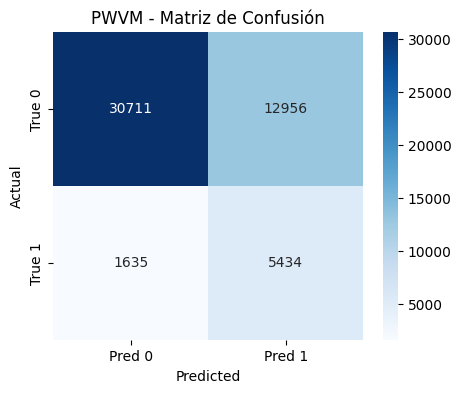

In [211]:
cm = confusion_matrix(y_test, y_pred_pwvm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('PWVM - Matriz de Confusión')
plt.show()

In [212]:
acc = accuracy_score(y_test, y_pred_pwvm)
prec = precision_score(y_test, y_pred_pwvm)
rec = recall_score(y_test, y_pred_pwvm)
f1 = f1_score(y_test, y_pred_pwvm)

print(f"Accuracy:  {acc:.6f}")
print(f"Precision: {prec:.6f}")
print(f"Recall:    {rec:.6f}")
print(f"F1-score:  {f1:.6f}")

Accuracy:  0.712413
Precision: 0.295487
Recall:    0.768708
F1-score:  0.426882


### **Análisis de las métricas**

El PWVM muestra un compromiso aceptable entre sensibilidad y especificidad, optimizado para el contexto médico donde los falsos negativos (no detectar diabetes real) tienen consecuencias más graves que los falsos positivos (estudios adicionales en pacientes sanos).

#### **Accuracy: 71.24%**

El modelo acierta en aproximadamente 7 de cada 10 predicciones

Valor aceptable para un problema médico complejo, pero limitado por el desbalance de clases

#### **Precision: 29.55%**

Solo el 29.55% de los casos predichos como diabéticos realmente lo son

Alto número de falsas alarmas, lo que podría generar:

- Costos adicionales en pruebas de confirmación

- Sobrecarga del sistema de salud

#### **Recall: 76.87%**

El modelo detecta el 76.87% de todos los casos reales de diabetes

Excelente sensibilidad para un screening médico:

* Pocos casos pasan desapercibidos

* Fundamental para diagnóstico temprano

#### **F1-Score: 42.69%**

Puntuación balanceada moderada-baja, refleja el trade-off entre Precision y Recall

Valor esperado dado la compensación intencional entre métricas

## **Consideraciones e Implicaciones**

**Adaptación entre dominios drásticamente diferentes**

La implementación del PWVM originalmente diseñado para detección de fallas en microgrids hacia predicción de diabetes representa un caso notable de transferencia de metodologías entre dominios muy diferentes:

* **Diferencia en el Dataset**: Mientras el paper original utilizaba señales de corriente transitoria con patrones temporales definidos, el dataset de diabetes maneja variables estáticas de salud con relaciones no lineales complejas

* **Naturaleza de las Features**: Las señales eléctricas presentan correlaciones físicas predecibles, mientras los indicadores de salud exhiben interacciones biológicas multivariadas

* **Balance de Clases**: El contexto médico presenta desbalance natural mucho más pronunciado que en sistemas de potencia

**Implicaciones de la Reducción Multiclase a Binario**

La adaptación de 11 clases a 2 clases implica:

* **Simplificación del esquema de pesos**: La matriz de pesos 4×11 del paper original se reduce a estructura 5×2

* **Pérdida de granularidad**: El modelo original discriminaba entre múltiples tipos de fallas, mientras nuestro caso solo distingue presencia/ausencia

* **Mayor desafío de calibración**: En problemas multiclase los errores se distribuyen, en binario los falsos positivos/negativos tienen impacto directo

**Reflexión Final**

El AUC de 0.8107, aunque competitivo, tiene margen significativo de mejora. La naturaleza conservadora del modelo (alto recall, baja precision) es clínicamente apropiada pero sugiere que el PWVM está subutilizando patrones complejos en los datos.